# Self-Supervised Pretraining with SimCLR

A CPU-friendly demonstration of self-supervised contrastive learning. The model learns image representations without using class labels during pretraining.

**Pipeline:** image → two augmentations → encoder → projection head → NT-Xent loss → embeddings → similarity search.


In [1]:
import os, pickle, tarfile
from pathlib import Path
import requests
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

SEED=42
torch.manual_seed(SEED); np.random.seed(SEED)
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
DATA_DIR=ROOT/"data"; MODEL_DIR=ROOT/"models"
DATA_DIR.mkdir(exist_ok=True); MODEL_DIR.mkdir(exist_ok=True)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 1. Download CIFAR-10

The open-source CIFAR-10 archive is downloaded only when needed. We intentionally use a small subset so the experiment is practical without a GPU.


In [2]:
url="https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
archive=DATA_DIR/"cifar-10-python.tar.gz"
if not archive.exists():
    r=requests.get(url,stream=True,timeout=60); r.raise_for_status()
    with open(archive,"wb") as f:
        for chunk in r.iter_content(1024*1024):
            if chunk: f.write(chunk)
extract_dir=DATA_DIR/"cifar-10-batches-py"
if not extract_dir.exists():
    with tarfile.open(archive,"r:gz") as tar: tar.extractall(DATA_DIR)
print("Ready:",extract_dir)


Ready: c:\Users\user\Desktop\Self-Supervised-Pretraining\data\cifar-10-batches-py


In [3]:
def load_batch(path):
    with open(path,"rb") as f: b=pickle.load(f,encoding="bytes")
    x=b[b"data"].reshape(-1,3,32,32).transpose(0,2,3,1)
    y=np.array(b[b"labels"])
    return x,y

images,labels=load_batch(extract_dir/"data_batch_1")
MAX_IMAGES=2000
images,labels=images[:MAX_IMAGES],labels[:MAX_IMAGES]
print(images.shape,labels.shape)


(2000, 32, 32, 3) (2000,)


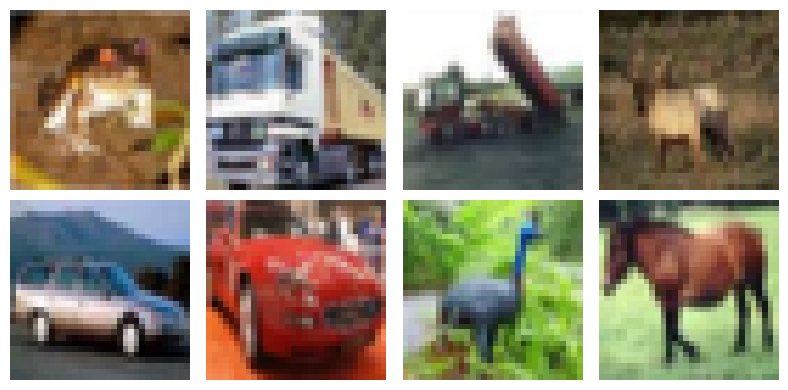

In [4]:
plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1); plt.imshow(images[i]); plt.axis("off")
plt.tight_layout(); plt.show()


## 2. Generate two augmented views

Each image is independently transformed twice. The two outputs form a positive pair; class labels are not used.


In [5]:
transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(32,scale=(0.65,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.4,0.1)],p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
])
class ContrastiveCIFAR(Dataset):
    def __init__(self,images,transform): self.images,self.transform=images,transform
    def __len__(self): return len(self.images)
    def __getitem__(self,i): return self.transform(self.images[i]),self.transform(self.images[i])
dataset=ContrastiveCIFAR(images,transform)
loader=DataLoader(dataset,batch_size=64,shuffle=True,num_workers=0)


## 3. Compact encoder and projection head

A small CNN is deliberately used instead of a large ViT so the repository remains usable on a CPU-only computer. The encoder can later be replaced with a ViT when GPU resources are available.


In [6]:
class SmallEncoder(nn.Module):
    def __init__(self,embedding_dim=128):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.AdaptiveAvgPool2d(1))
        self.fc=nn.Linear(128,embedding_dim)
    def forward(self,x): return self.fc(self.features(x).flatten(1))

class ProjectionHead(nn.Module):
    def __init__(self,in_dim=128,hidden_dim=128,out_dim=64):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(in_dim,hidden_dim),nn.ReLU(),nn.Linear(hidden_dim,out_dim))
    def forward(self,x): return self.net(x)

encoder=SmallEncoder().to(DEVICE); projector=ProjectionHead().to(DEVICE)
print("Parameters:",sum(p.numel() for p in list(encoder.parameters())+list(projector.parameters())))


Parameters: 134976


## 4. NT-Xent contrastive loss

Normalized embeddings are compared with cosine similarity. The other examples in the batch provide negative examples.


In [7]:
def nt_xent_loss(z1,z2,temperature=0.5):
    z1,z2=F.normalize(z1,dim=1),F.normalize(z2,dim=1)
    z=torch.cat([z1,z2],0); n=z1.size(0)
    sim=z@z.T
    mask=torch.eye(2*n,device=z.device,dtype=torch.bool)
    sim=sim.masked_fill(mask,-9e15)
    targets=torch.cat([torch.arange(n,device=z.device)+n,torch.arange(n,device=z.device)])
    return F.cross_entropy(sim/temperature,targets)


## 5. CPU-friendly pretraining

Three epochs on 2,000 images provide a reproducible portfolio demonstration. Increase `MAX_IMAGES` or `EPOCHS` when more compute is available.


In [8]:
EPOCHS=3
optimizer=torch.optim.Adam(list(encoder.parameters())+list(projector.parameters()),lr=1e-3,weight_decay=1e-6)
loss_history=[]
encoder.train(); projector.train()
for epoch in range(EPOCHS):
    total=0
    for v1,v2 in loader:
        v1,v2=v1.to(DEVICE),v2.to(DEVICE)
        z1=projector(encoder(v1)); z2=projector(encoder(v2))
        loss=nt_xent_loss(z1,z2)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total+=loss.item()
    value=total/len(loader); loss_history.append(value)
    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {value:.4f}")


Epoch 1/3 - loss: 4.1133
Epoch 2/3 - loss: 3.8234
Epoch 3/3 - loss: 3.7023


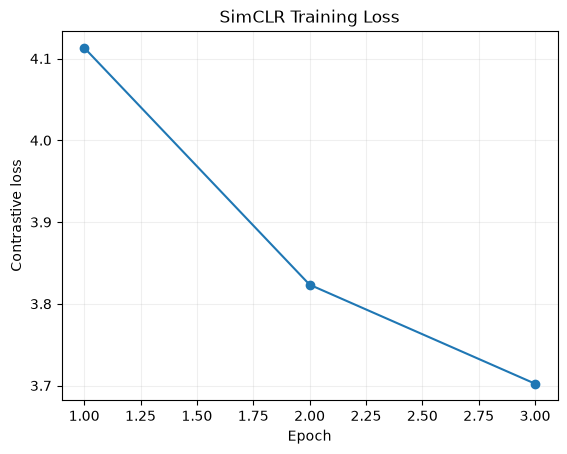

In [9]:
plt.plot(range(1,EPOCHS+1),loss_history,marker="o")
plt.xlabel("Epoch"); plt.ylabel("Contrastive loss"); plt.title("SimCLR Training Loss")
plt.grid(alpha=.2); plt.show()


## 6. Save the pretrained encoder

The projection head is used during contrastive training; the encoder is the reusable representation model.


In [10]:
encoder_path=MODEL_DIR/"simclr_encoder.pth"
torch.save({"model_state_dict":encoder.state_dict(),"embedding_dim":128,
            "method":"SimCLR-style contrastive pretraining"},encoder_path)
print("Saved:",encoder_path)


Saved: c:\Users\user\Desktop\Self-Supervised-Pretraining\models\simclr_encoder.pth


## 7. Extract embeddings

Labels are used only after pretraining for visualization. This does not affect the self-supervised training stage.


In [11]:
eval_transform=transforms.Compose([
    transforms.ToPILImage(),transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
])
encoder.eval(); all_embeddings=[]
with torch.no_grad():
    for start in range(0,len(images),128):
        batch=torch.stack([eval_transform(x) for x in images[start:start+128]]).to(DEVICE)
        all_embeddings.append(encoder(batch).cpu().numpy())
embeddings=np.concatenate(all_embeddings)
print("Embedding matrix:",embeddings.shape)


Embedding matrix: (2000, 128)


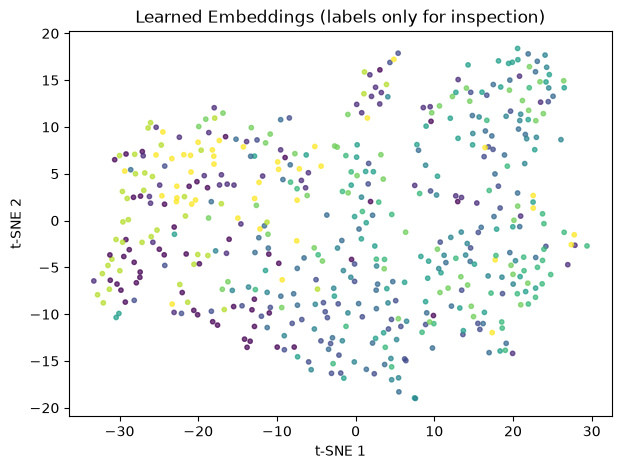

In [12]:
n=min(500,len(embeddings))
idx=np.random.default_rng(SEED).choice(len(embeddings),n,replace=False)
coords=TSNE(n_components=2,random_state=SEED,perplexity=30,init="pca").fit_transform(embeddings[idx])
plt.figure(figsize=(7,5)); plt.scatter(coords[:,0],coords[:,1],c=labels[idx],s=10,alpha=.7)
plt.title("Learned Embeddings (labels only for inspection)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.show()


## 8. Similarity search

The learned representation can be used for image retrieval. We retrieve the nearest embeddings using cosine similarity.


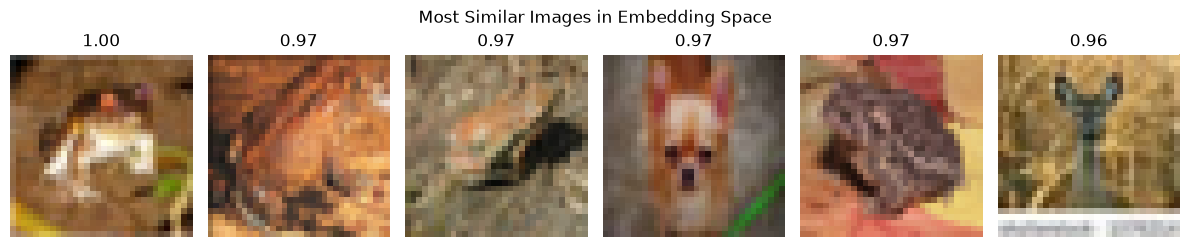

In [13]:
query=0
scores=cosine_similarity(embeddings[query:query+1],embeddings)[0]
nearest=np.argsort(scores)[-6:][::-1]
plt.figure(figsize=(12,2.5))
for pos,i in enumerate(nearest):
    plt.subplot(1,6,pos+1); plt.imshow(images[i]); plt.title(f"{scores[i]:.2f}"); plt.axis("off")
plt.suptitle("Most Similar Images in Embedding Space"); plt.tight_layout(); plt.show()


## Interview Takeaways

- Self-supervised learning learns representations without manually supplied labels.
- SimCLR creates positive pairs from two augmented views of the same image.
- Other samples in the mini-batch act as negatives.
- The projection head is mainly used for the contrastive objective.
- The encoder representation can support retrieval, k-NN, linear probing, or downstream fine-tuning.
- A compact CNN is used here for CPU practicality; the same workflow can be extended to a ViT on a GPU.
